<a href="https://colab.research.google.com/github/Aliyarovvv-Ali/_test_repository/blob/main/%D0%9F%D1%80%D0%BE%D0%B5%D0%BA%D1%82_Data_Science.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Анализ данных

В этом ноутбуке вы будете выполнять свой Data Science проект. Используйте его в качестве шаблона. По необходимости добавляйте ячейки с кодом и текстом. Ссылку на свой ноутбук отправьте своему преподавателю.



## План работы

1. Начни выполнять свой Data Science проект. Используй план работы:

    1. Сформулируйте задачу
    2. Подготовьте описание датасета
    3. Опишите признаки
    4. Найдите пропуски
    5. Посчитайте основные статистики
    6. Напишите свои выводы


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix

df = pd.read_csv('/content/credit.csv')
df.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


## 1. Задача проекта

Определите, какую конкретную задачу вы хотите решить с использованием выбранного датасета.

**Цель**: Анализ данных для создания модели, определяющей одобрит клиент кредит или нет

**Тип задачи**: Классификация

## 2. Описание датасета

Создайте краткое описание датасета, указав его общую тематику, источник, количество записей.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


**Тематика:** Данные характеристиками клиентов банка

**Источник:** Предоставленные датасеты

**Количество записей:** 614

**Количество признаков:** 12 + 1 целевой признак `Loan_Status`

**Целевая переменная:** `Loan_Status` (Y - одобрит кредит, N - нет)

## 3. Описание признаков

Проведите анализ признаков в датасете. Опишите, что представляют собой различные признаки, их типы (категориальные, числовые) и возможные взаимосвязи.

# Признаки датасета

## Количественные признаки

`ApplicantIncome` Доход заявителя

`CoapplicantIncome` Доход созаявителя

`LoanAmount` Сумма кредита

`Loan_Amount_Term` Срок предоставления кредита

## Категориальные признаки

`Loan_ID` ID кредита

`Gender` Пол заемщика

`Married` Состоит в браке или нет

`Dependents` Количество иждивенцев

`Education` Образование

`Self_Employed` Является ли частным предпринимателем

`Credit_History` Есть ли хорошая кредитная история (1 - да, 0 - нет)

`Property_Area` Тип района, где находится недвижимость

`Loan_Status` Одобрение кредита (Y - да, N - нет)

## 4. Пропуски

Найдите пропущенные значения в данных. Это поможет определить, насколько полные и надежные ваши данные, и подготовиться к их обработке.


In [ ]:
missing_data = df.isna().sum()
missing_persent = (missing_data / len(df)) * 100
missing_persent

,0
Loan_ID,0.000000
Gender,2.117264
Married,0.488599
Dependents,2.442997
Education,0.000000
Self_Employed,5.211726
ApplicantIncome,0.000000
CoapplicantIncome,0.000000
LoanAmount,3.583062
Loan_Amount_Term,2.280130


## 5. Статистики

Вычислите основные статистики для числовых и категориальных признаков: среднее, медиану, стандартное отклонение, моду. Это предоставит вам общее представление о распределении данных.

In [ ]:
df.drop("ApplicantIncome", axis=1).describe()

,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,592.000000,600.00000,564.000000
mean,1621.245798,146.412162,342.00000,0.842199
std,2926.248369,85.587325,65.12041,0.364878
min,0.000000,9.000000,12.00000,0.000000
25%,0.000000,100.000000,360.00000,1.000000
50%,1188.500000,128.000000,360.00000,1.000000
75%,2297.250000,168.000000,360.00000,1.000000
max,41667.000000,700.000000,480.00000,1.000000


# Статистика категориальных признаков



In [ ]:
df.describe(include="object")

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP002990,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


## Статистика ApplicantIncome



In [ ]:
print("Доход заявителя (ApplicantIncome)")
print(f"Средний {df["ApplicantIncome"].mean():.0f}")
print(f"Медиана {df["ApplicantIncome"].median():.0f}")
print(f"Низкий (<3000) {len(df[df["ApplicantIncome"] < 3000])} чел.")
print(f"Средний (3000-6000) {len(df[(df["ApplicantIncome"] >= 3000) & (df["ApplicantIncome"] <= 6000)])} чел.")
print(f"Высокий (>6000) {len(df[df["ApplicantIncome"] > 6000])} чел.")

Доход заявителя (ApplicantIncome)
Средний 5403
Медиана 3812
Низкий (<3000) 174 чел.
Средний (3000-6000) 303 чел.
Высокий (>6000) 137 чел.


## 6. Выводы

Сделайте обобщенные выводы на основе предыдущих шагов. Опишите, какие аспекты данных требуют внимания, и сформулируйте предварительные гипотезы для дальнейшего исследования.





1. **Качество данных** Присутствуют пропуски (149): `Gender`: 13, `Married`: 3, `Dependents`: 15, `Self_Employed`: 32, `LoanAmount`: 22, `Loan_Amount_Term`: 14, `Credit_History`: 50.

    Дубликаты отстутствуют.

    `Credit_History`: категориальный признак записан через цифры (0 - нет хорошей кредитной истории, 1 - есть)

2. **Различия по целевому признаку** Вывод: с целевым признаком хорошо коррелируют доход (бо́льший доход увеличивает вероятность одобрения), а также наличие хорошей кредитной истории.

3. **Наблюдения по количественным и категориальным признакам** В количественных признаках присутствуют крупные выбросы, в категориальных признаках есть заметный перевес мужчин относительно женщин, а также людей состоявших в браке и имеющих образование.

4. **Рекомендации к предобработке** Рекомендуется заполнить пропуски (числовые - медианой, категориальные - модой), выбросы лучше оставить, а также закодировать категориальные признаки (например `Gender`: Мужчины = 1, Женщины = 0) и масштабировать числовые в диапазоне от 0 до 1.

# Визуализация

## План работы

1. Сформулируйте цель визуализации
2. Подготовьте данные для визуализации
3. Выберите подходящие инструменты
4. Постройте визуализации
5. Напишите свои выводы


## 1. Цель визуализации

Определите, какую информацию вы хотели бы передать с помощью визуализации данных. Например, можете ли вы визуализировать зависимость между различными признаками или выделить особенности распределения данных.

**Цель** Визуализировать соотношение клиентов банка, одобривших и не одобривших кредит и влияющих на это признаки.

**Распределение целевой переменной**

**Распределение количественных признаков**

**Распределение категориальных признаков**

**Построить матрицу корреляции и тепловую карту**

**Сравнить клиентов, одобривших кредит и не одобривших**

## 2. Подготовка данных

Обработайте данные, если это необходимо для визуализации. Например, преобразуйте форматы данных, устраните выбросы или заполните/удалите пропуски.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [ ]:
df.isna().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
# Заполнение пропусков

df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

/tmp/ipykernel_2647/974839024.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
/tmp/ipykernel_2647/974839024.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

In [ ]:
df.isna().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


## 3. Выбор подходящих инструментов

Вспомните различные виды графиков и диаграмм, которые могут быть эффективными для передачи выбранной информации. Выберите те, которые наилучшим образом соответствуют вашей цели.


## Для визуализации будут использоваться библиотеки matplotlib и seaborn

1. Количественные признаки - гистограммы

2. Категориальные признаки - столбчатые диаграммы

3. Проверка на наличие выбросов - ящик с усами

4. Корреляция - тепловая карта

5. Распределение целевой переменной - круговая диаграмма

## 4. Построение визуализаций

Используйте выбранные виды графиков для создания визуальных представлений ваших данных. Обращайте внимание на читаемость и понятность графиков.


## Количественные признаки (гистограммы)

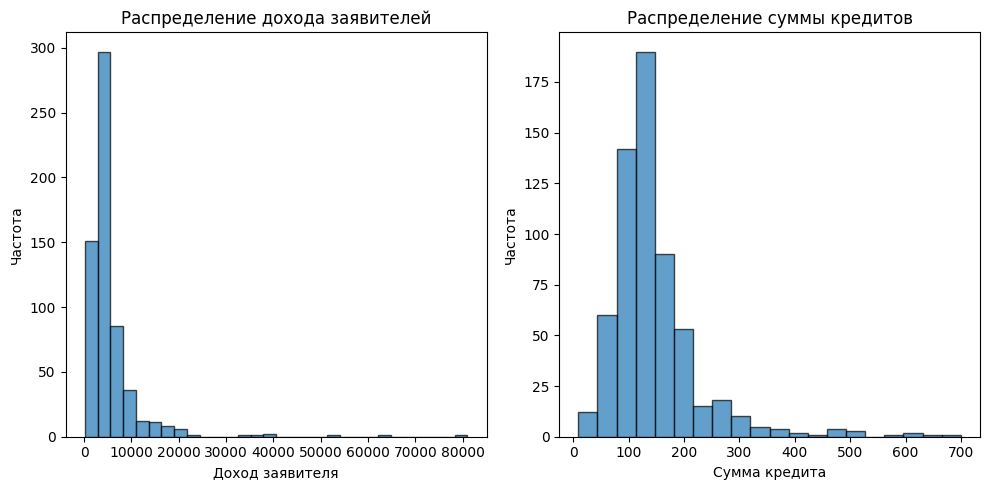

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].hist(df['ApplicantIncome'], bins=30, edgecolor="black", alpha=0.7)
axes[0].set_title("Распределение дохода заявителей")
axes[0].set_xlabel("Доход заявителя")
axes[0].set_ylabel("Частота")

axes[1].hist(df['LoanAmount'], bins=20, edgecolor="black", alpha=0.7)
axes[1].set_title("Распределение суммы кредитов")
axes[1].set_xlabel("Сумма кредита")
axes[1].set_ylabel("Частота")

plt.tight_layout()
plt.show()

## Категориальные признаки (столбчатые диаграммы)

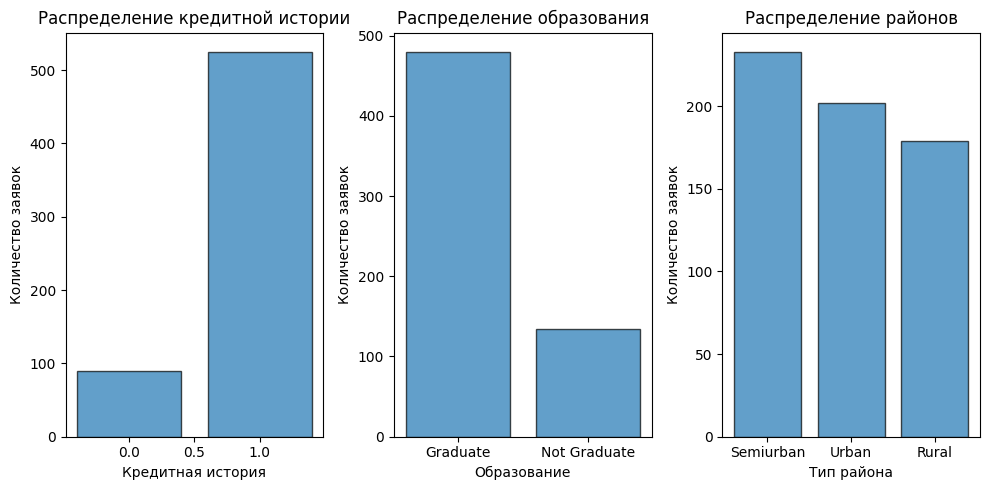

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(10, 5))
credit_counts = df['Credit_History'].value_counts()
axes[0].bar(credit_counts.index, credit_counts.values, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Кредитная история")
axes[0].set_ylabel("Количество заявок")
axes[0].set_title("Распределение кредитной истории")

education_counts = df['Education'].value_counts()
axes[1].bar(education_counts.index, education_counts.values, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Образование")
axes[1].set_ylabel("Количество заявок")
axes[1].set_title("Распределение образования")

area_counts = df['Property_Area'].value_counts()
axes[2].bar(area_counts.index, area_counts.values, edgecolor="black", alpha=0.7)
axes[2].set_xlabel("Тип района")
axes[2].set_ylabel("Количество заявок")
axes[2].set_title("Распределение районов")

plt.tight_layout()
plt.show()

## Выбросы

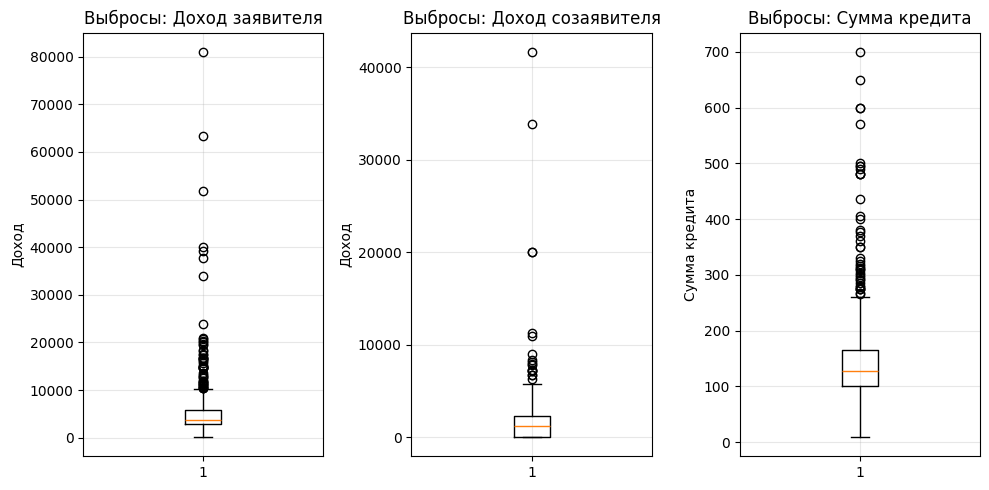

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(10, 5))
axes[0].boxplot(df['ApplicantIncome'])
axes[0].set_title('Выбросы: Доход заявителя')
axes[0].set_ylabel('Доход')
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(df['CoapplicantIncome'])
axes[1].set_title('Выбросы: Доход созаявителя')
axes[1].set_ylabel('Доход')
axes[1].grid(True, alpha=0.3)

axes[2].boxplot(df['LoanAmount'])
axes[2].set_title('Выбросы: Сумма кредита')
axes[2].set_ylabel('Сумма кредита')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Тепловые карты

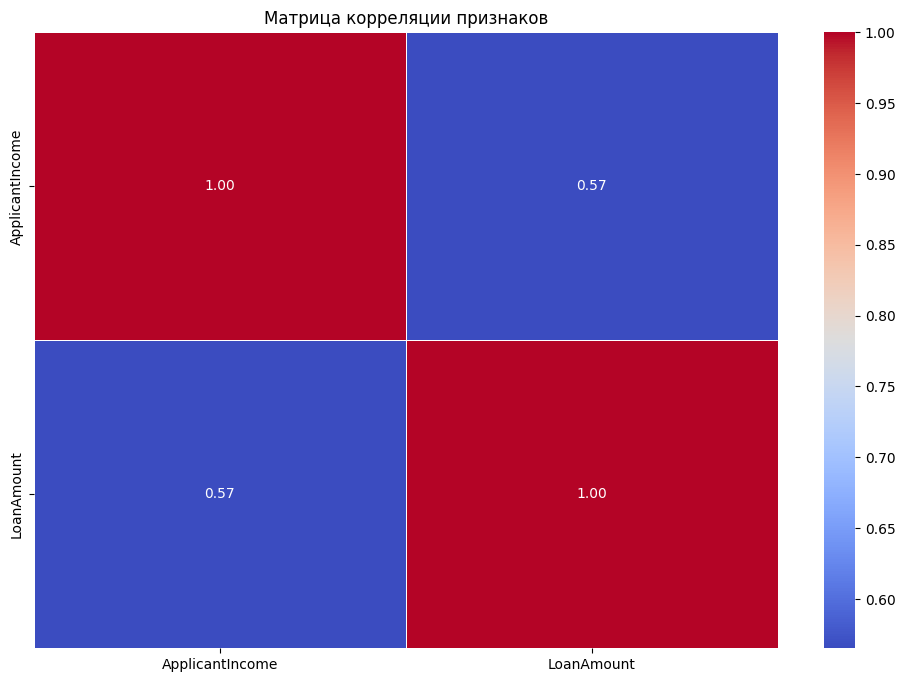

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[['ApplicantIncome', 'LoanAmount']].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Матрица корреляции признаков')
plt.show()

## Распределение целевой переменной

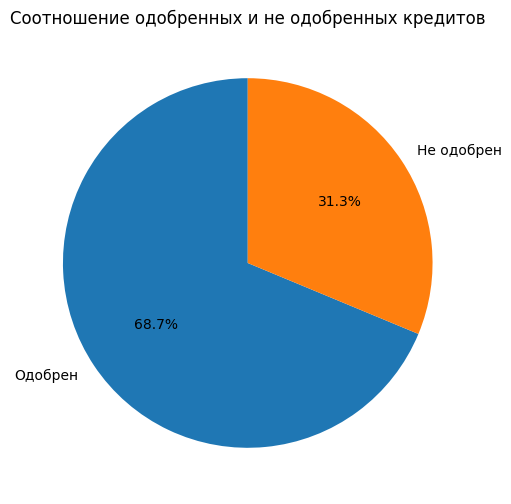

In [ ]:
target_counts = df['Loan_Status'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(target_counts, labels=["Одобрен", "Не одобрен"], autopct="%1.1f%%", startangle=90)
plt.title("Соотношение одобренных и не одобренных кредитов")
plt.show()

## 5. Выводы

Проанализируйте полученные визуализации и сделайте выводы. Обратите внимание на выявленные закономерности, аномалии или интересные тренды.

**Выводы по визуализации (наличие дисбаланса классов):** Сильного дисбаланса классов нет, модели хватает данных для обучения

**Наличие выбросов:** Присутствуют сильные выбросы в `ApplicantIncome` и `CoapplicantIncome` (доходах заявителей и созаявителей), но их лучше не удалять

**Форма графиков и закономерности:** Графики стабильные, видно, что преобладают заявители с образованием, хорошей кредитной историей и из пригородного места жительства, а также с доходом около 5000

**Рекомендации для моделирования:** Закодировать категориальные признаки и масштабировать числовые. Разделить данные на тренировочную и тестовую выборку и провести оценку по метрикам, также можно удалить Loan_ID (т.к. он не влияет на результат)

# Машинное обучение

## План работы

1. Подготовьте данные
2. Выберите и обучите модель для вашей задачи
3. Оцените качество модели
4. Интерпретируйте результаты модели
5. Напишите свои выводы

## 1. Подготовка данных

Разделите датасет на обучающую и тестовую выборки, обработайте пропущенные значения, выполните кодирование категориальных признаков и масштабирование числовых признаков.

## Кодировка категориальных признаков

In [ ]:
for col in ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Loan_Status']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

df = pd.get_dummies(df, columns=['Property_Area'], drop_first=True)

In [ ]:
df = df.drop('Loan_ID', axis=1)
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
print(f"Распределение в обучающей выборке: одобривших кредит - {(y_train == "Y").sum()}, не одобривших - {(y_train == "N").sum()}")
print(f"Распределение в тестовой выборке: одобривших кредит - {(y_test == "Y").sum()}, не одобривших - {(y_test == "N").sum()}")

Распределение в обучающей выборке: одобривших кредит - 0, не одобривших - 0
Распределение в тестовой выборке: одобривших кредит - 0, не одобривших - 0


## Масштабирование числовых признаков

In [ ]:
scaler = StandardScaler()

num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# 2. Выбор и обучение модели

Выберите подходящий тип модели для вашей задачи (регрессия, классификация и т. д.), обучите модель, получите предсказания на тестовой выборке.

## Логистическая регрессия

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

## 3. Оценка качества модели

Оцените качество модели на тестовой выборке с использованием подходящих метрик.
Сравните результаты с ожидаемыми значениями и проанализируйте результаты.

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy {accuracy * 100:.1f}%")
print(f"Precision {precision * 100:.1f}%")
print(f"Recall {recall * 100:.1f}%")
print(f"F1-score {f1:.4f}")

Accuracy 78.4%
Precision 75.6%
Recall 98.3%
F1-score 0.8551


## Матрица ошибок и тепловая карта

In [ ]:
cm = confusion_matrix(y_test, y_pred)

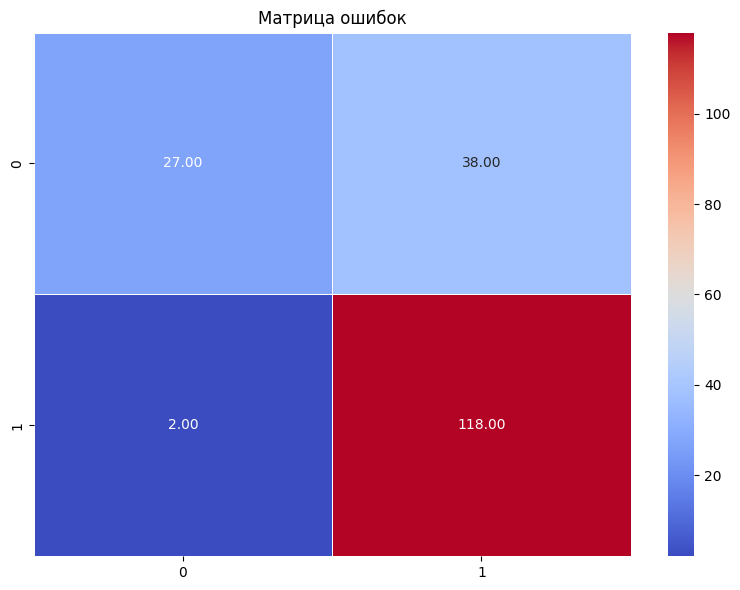

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Матрица ошибок")
plt.tight_layout()
plt.show()

## Цена ошибки

1. Ошибка: ложное одобрение. Цена: высокая - банк может потерять денег, одобрив неподходящего клиента

2. Ошибка: ложный отказ. Цена: средняя - банк может лишиться подходящего клиента

## 4. Интерпретация результатов

Попробуйте интерпретировать, как модель принимает решения и какие признаки оказывают наибольшее влияние. Рассмотрите важность признаков и проверьте, соответствуют ли результаты ожиданиям.

## Веса признаков

In [ ]:
coefs = pd.DataFrame({"Признак": X_train.columns, "Вес": model.coef_[0]}).sort_values("Вес", ascending=False)
coefs

,Признак,Вес
9,Credit_History,3.244625
10,Property_Area_Semiurban,0.891523
1,Married,0.541257
2,Dependents,0.175656
8,Loan_Amount_Term,0.090678
11,Property_Area_Urban,0.073610
4,Self_Employed,0.018444
6,CoapplicantIncome,-0.044649
7,LoanAmount,-0.056387
5,ApplicantIncome,-0.068338


По таблице видно что самый влиятельный с отрывом признак: `Credit_History`, далее идут `Property_Area_Semiurban` и `Married`, а `Gender` или `Education` наоборот уменьшают вероятность одобрения

## 5. Выводы и итоги

Сделайте обзор результатов, напишите свои выводы по итогам всего проекта.

**Что сделано:** Целью проекта было обучение модели, определяющей одобрит человек кредит или нет, модель была обучена на базе логистической регрессии

**Качество модели:** Модель показала неплохие метрики, особенно высока полнота (Recall): 98% - модель почти всегда правильно определяет одобренный кредит, F1-score также показывает хорошее соотношение: 85,5%

**Самые важные признаки:** Больше всего на одобрение кредита влияют наличие хорошей кредитной истории и место проживания - пригород

**Цена ошибок:** Цена ложного одобрения: высокая, ложного отказа: средняя

**Что можно улучшить/добавить:** При желании можно было-бы уменьшить или увеличить порога входа что-бы улучшить результаты желаемых метрик